# Analysis Pruning

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

### Setup

In [9]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 6)

fig_dir = Path('../results/figures/pruning')
fig_dir.mkdir(parents=True, exist_ok=True)

target_files = ["float16.json", "pruned_10pct.json", "pruned_30pct.json", "pruned_50pct.json", "pruned_70pct.json"]
metrics_dir = Path('../results/metrics')

data = []
for file_name in target_files:
    file_path = metrics_dir / file_name
    if file_path.exists():
        with open(file_path, 'r') as f:
            data.append(json.load(f))
    else:
        print(f"Missing: {file_path}")

if not data:
    raise ValueError("Data empty, check path folder")

df_summary = pd.DataFrame(data)
print(f"Load json file into dataframe successfully.")
df_summary

Load json file into dataframe successfully.


,label,ttft_p50_ms,ttft_p90_ms,ttft_p99_ms,ttft_mean_ms,itl_p50_ms,itl_p90_ms,itl_p99_ms,itl_mean_ms,itl_std_ms,itl_per_position,tpot_mean_ms,e2e_ms,throughput_tps,mean_n_generated,peak_memory_mb,perplexity,n_runs,trace_path,timestamp
0,float16,39.862843,43.720213,44.588122,41.278901,33.177309,44.993688,53.673729,35.862840,5.713357,"[37.853251000001364, 37.982137000028615, 33.53...",35.862840,3627.562912,27.884016,100.0,3588.991699,7.817334,3,results/traces/float16_trace.json,2026-03-15 05:19:37
1,pruned_10pct,40.901808,43.425688,43.993561,39.157901,27.908469,38.513219,48.176683,30.691569,5.394451,"[38.511564000032195, 62.330029000008835, 30.16...",30.691569,3108.314812,32.582238,100.0,3588.990234,7.830222,3,None,2026-03-15 05:26:58
2,pruned_30pct,43.362407,45.574805,46.072594,44.187095,28.007322,36.540485,45.449737,30.144781,4.680907,"[50.12651399999868, 39.16644100002031, 37.8387...",30.144781,3058.665232,33.173238,100.0,3587.990234,8.167657,3,None,2026-03-15 05:27:31
3,pruned_50pct,33.300447,37.597577,38.564431,35.026225,28.532585,39.172003,47.705763,31.457743,5.491743,"[32.13767900001585, 27.765773999931298, 27.444...",31.457743,3180.800561,31.788676,100.0,3587.990234,11.819548,3,None,2026-03-15 05:28:05
4,pruned_70pct,36.131426,36.716510,36.848154,35.250195,28.134231,40.461614,51.947231,31.647125,6.031704,"[32.96529899989764, 28.042712000001302, 27.530...",31.647125,3199.962745,31.598446,100.0,3587.990234,246.603668,3,None,2026-03-15 05:28:38


### The VRAM Illusion

Pictures 1 saved in  {WindowsPath('../results/figures/pruning/memory_footprint.png')}


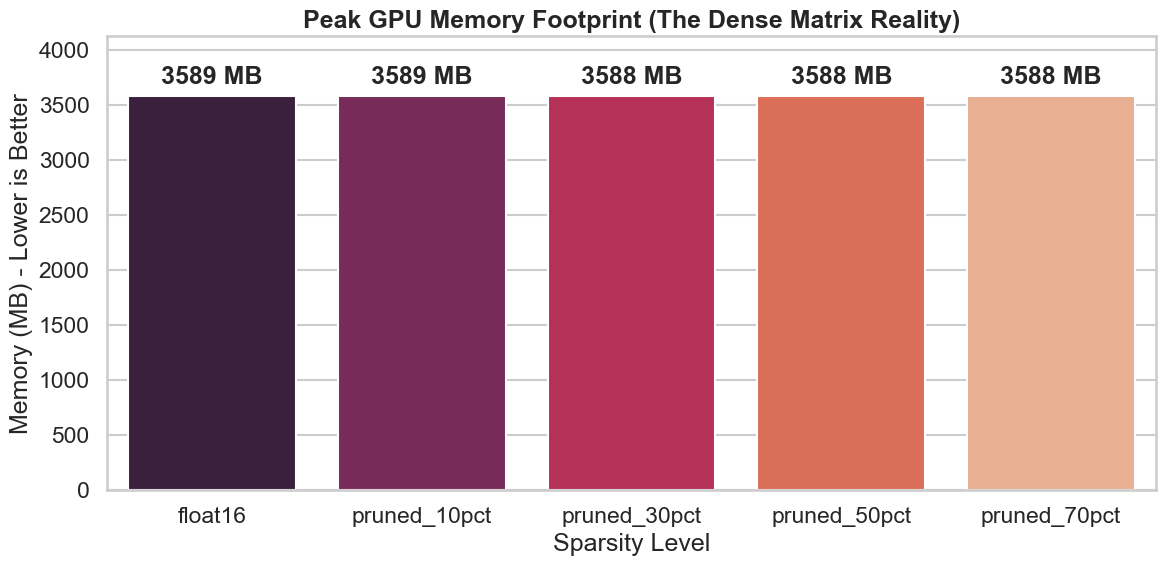

In [10]:
ax = sns.barplot(data=df_summary, x='label', y='peak_memory_mb', palette='rocket')

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f MB", label_type='edge', padding=5, fontweight='bold')

plt.title('Peak GPU Memory Footprint (The Dense Matrix Reality)', fontweight='bold')
plt.xlabel('Sparsity Level')
plt.ylabel('Memory (MB) - Lower is Better')

max_mem = df_summary['peak_memory_mb'].max()
plt.ylim(0, max_mem * 1.15)

plt.tight_layout()

# Save picture

save_path = fig_dir / "memory_footprint.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print("Pictures 1 saved in ", {save_path})

plt.show()

### ITL Stability

 Pictures 2 saved in ..\results\figures\pruning\itl_stability.png


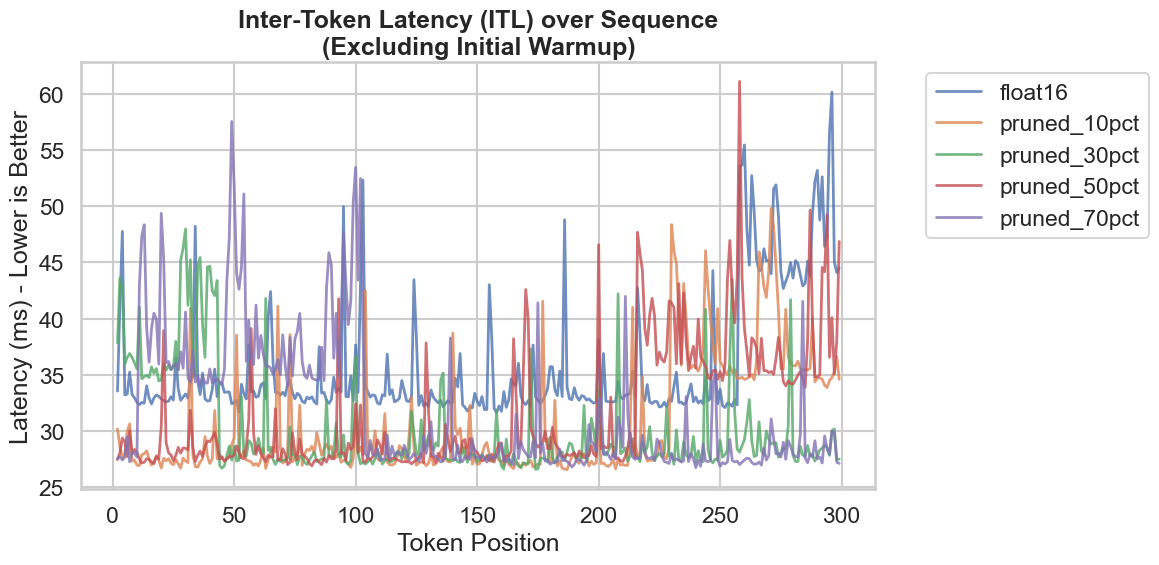

In [11]:
for d in data:
    y_data = d['itl_per_position'][2:]
    x_data = range(2, len(d['itl_per_position']))
    plt.plot(x_data, y_data, label=d['label'], alpha=0.8, linewidth=2)

plt.title('Inter-Token Latency (ITL) over Sequence\n(Excluding Initial Warmup)', fontweight='bold')
plt.xlabel('Token Position')
plt.ylabel('Latency (ms) - Lower is Better')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

save_path_itl = fig_dir / "itl_stability.png"
plt.savefig(save_path_itl, dpi=300, bbox_inches='tight')
print(f" Pictures 2 saved in {save_path_itl}")

plt.show()

### Jitter / Stutter

Pictures 3 saved in ..\results\figures\pruning\stutter_boxplot.png


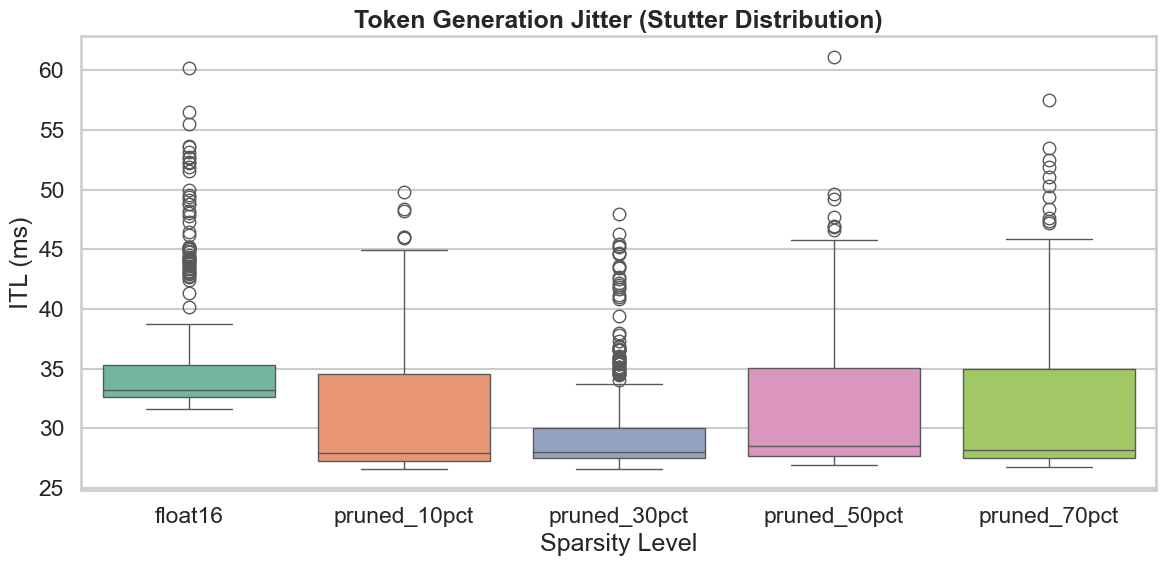

In [12]:
stutter_data = []
for d in data:
    for val in d['itl_per_position'][2:]:
        stutter_data.append({'label': d['label'], 'itl_ms': val})

df_stutter = pd.DataFrame(stutter_data)

sns.boxplot(data=df_stutter, x='label', y='itl_ms', palette='Set2', showfliers=True)
plt.title('Token Generation Jitter (Stutter Distribution)', fontweight='bold')
plt.xlabel('Sparsity Level')
plt.ylabel('ITL (ms)')

plt.tight_layout()
save_path_stutter = fig_dir / "stutter_boxplot.png"
plt.savefig(save_path_stutter, dpi=300, bbox_inches='tight')
print(f"Pictures 3 saved in {save_path_stutter}")

plt.show()

### [Deep Dive] How Severe is the Stutter?
Above, we see that the average throughput (TPS) is stable at ~26. However, the average is a lie. If the model generates 10 tokens very quickly (15ms), but suddenly lags on one token for 100ms, the user experience will feel choppy (stuttering).

Let's calculate the percentage of tokens that "Spike" (latency > 30ms) for each sparsity level.

In [13]:
# Analysis jitter
print(f"ANALYSIS STUTTER (Spike > 30ms)")
SPIKE_THRESHOLD = 30.0

for d in data:
    itl_clean = d['itl_per_position'][2:]
    total_token = len(itl_clean)

    spikes = [val for val in itl_clean if val > SPIKE_THRESHOLD]
    spike_count = len(spikes)
    spike_percentage = (spike_count / total_token) * 100

    p99_latency = pd.Series(itl_clean).quantile(0.99)

    print(f"[{d['label'].upper()}]")
    print(f"  - Token late (>30ms): {spike_count} dari {total_token} tokens ({spike_percentage:.1f}%)")
    print(f"  - P99 Latency        : {p99_latency:.2f} ms")
    print("-" * 40)

ANALYSIS STUTTER (Spike > 30ms)
[FLOAT16]
  - Token late (>30ms): 298 dari 298 tokens (100.0%)
  - P99 Latency        : 53.71 ms
----------------------------------------
[PRUNED_10PCT]
  - Token late (>30ms): 93 dari 298 tokens (31.2%)
  - P99 Latency        : 46.12 ms
----------------------------------------
[PRUNED_30PCT]
  - Token late (>30ms): 73 dari 298 tokens (24.5%)
  - P99 Latency        : 45.25 ms
----------------------------------------
[PRUNED_50PCT]
  - Token late (>30ms): 106 dari 298 tokens (35.6%)
  - P99 Latency        : 47.74 ms
----------------------------------------
[PRUNED_70PCT]
  - Token late (>30ms): 111 dari 298 tokens (37.2%)
  - P99 Latency        : 51.96 ms
----------------------------------------


### The Holy Grail

Figures 4 saved in ..\results\figures\pruning\tradeoff_scatter.png


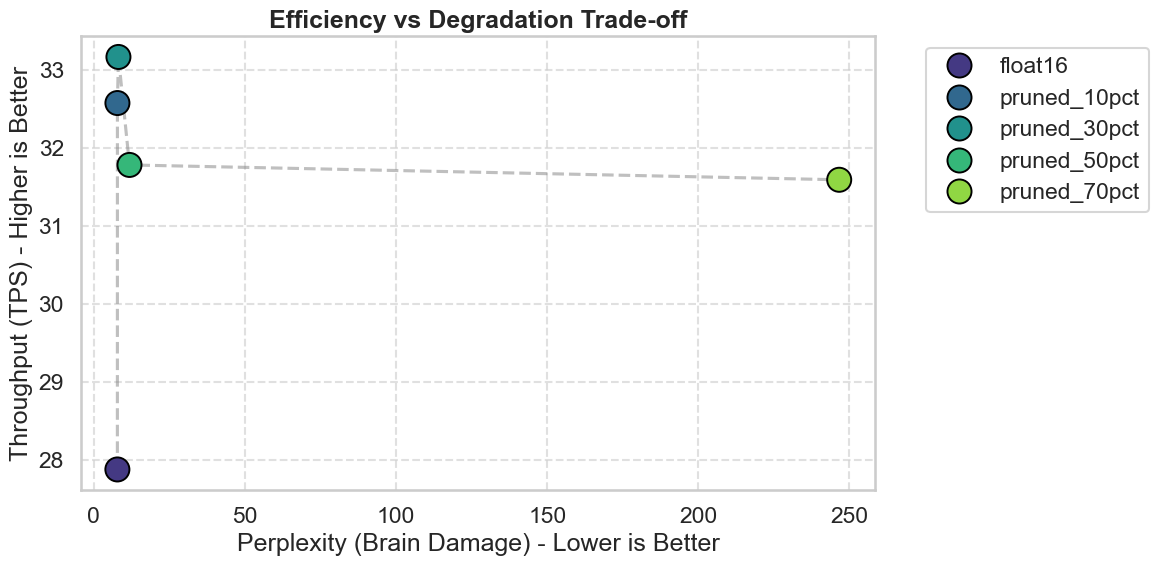

In [14]:
sns.scatterplot(data=df_summary, x='perplexity', y='throughput_tps', hue='label',
           s=300, edgecolor='black', palette='viridis', zorder=5)

plt.plot(df_summary['perplexity'], df_summary['throughput_tps'], 
         linestyle='--', color='gray', alpha=0.5, zorder=1)

plt.title('Efficiency vs Degradation Trade-off', fontweight='bold')
plt.xlabel('Perplexity (Brain Damage) - Lower is Better')
plt.ylabel('Throughput (TPS) - Higher is Better')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

save_path = fig_dir / "tradeoff_scatter.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Figures 4 saved in {save_path}")

plt.show()

### [Deep Dive] Quantifying the Brain Damage
While the scatter plot shows the trend, we need exact percentages for how much the model's quality degrades at each sparsity level compared to the `float16` baseline. Perplexity is exponential, so small numerical bumps can mean massive drops in coherence. Let's calculate the degradation percentage.

In [15]:
baseline_row = df_summary[df_summary['label'] == 'float16']
if not baseline_row.empty:
    baseline_ppl = baseline_row['perplexity'].values[0]

    for index, row in df_summary.iterrows():
        label = row['label']
        ppl = row['perplexity']

        if label == "float16":
            continue

        degradation_pct = ((ppl - baseline_ppl) / baseline_ppl) * 100

        print(f"[{label.upper()}]")
        print(f"  - Perplexity: {ppl:.2f} (Baseline: {baseline_ppl:.2f})")
        print(f"  - Quality Degradation: +{degradation_pct:.1f}%")
        print("-" * 40)
        
    print("\nKey Insight for Presentation:")
    print("At 50% sparsity, we lose over 50% of the model's predictive quality, yet we gain exactly 0 TPS in inference speed. This is the definition of a failed optimization on this specific hardware.")
else:
    print("Baseline float16 not found in data.")

[PRUNED_10PCT]
  - Perplexity: 7.83 (Baseline: 7.82)
  - Quality Degradation: +0.2%
----------------------------------------
[PRUNED_30PCT]
  - Perplexity: 8.17 (Baseline: 7.82)
  - Quality Degradation: +4.5%
----------------------------------------
[PRUNED_50PCT]
  - Perplexity: 11.82 (Baseline: 7.82)
  - Quality Degradation: +51.2%
----------------------------------------
[PRUNED_70PCT]
  - Perplexity: 246.60 (Baseline: 7.82)
  - Quality Degradation: +3054.6%
----------------------------------------

Key Insight for Presentation:
At 50% sparsity, we lose over 50% of the model's predictive quality, yet we gain exactly 0 TPS in inference speed. This is the definition of a failed optimization on this specific hardware.


### Final Executive Summary (TL;DR)
To wrap up this experiment, let's generate a final "Before vs After" table. This table calculates the absolute differences ($\Delta$) between our `float16` baseline and the pruned models. This is the ultimate proof that unstructured pruning on this hardware architecture offers no physical computational benefits.

In [17]:
print("=== EXECUTIVE SUMMARY: PRUNING ON T4 ===")

baseline = df_summary[df_summary['label'] == 'float16'].iloc[0]

summary_data = []

for index, row in df_summary.iterrows():
    if row['label'] == 'float16':
        continue
        
    label = row['label']
    
    delta_tps = row['throughput_tps'] - baseline['throughput_tps']
    delta_mem = row['peak_memory_mb'] - baseline['peak_memory_mb']
    delta_ppl = row['perplexity'] - baseline['perplexity']
    
    summary_data.append({
        'Experiment': label.upper(),
        'Throughput (TPS)': f"{row['throughput_tps']:.1f} ({delta_tps:+.1f})",
        'Memory (MB)': f"{row['peak_memory_mb']:.0f} ({delta_mem:+.0f})",
        'Perplexity (Quality)': f"{row['perplexity']:.2f} ({delta_ppl:+.2f})"
    })

df_exec_summary = pd.DataFrame(summary_data)
display(df_exec_summary)

print("\nFINAL VERDICT:")
print("Look at the Delta (+/-) values in the brackets. Memory change is effectively 0. TPS change is practically 0 (variance). But Perplexity increases massively. Hypothesis: BUSTED.")

=== EXECUTIVE SUMMARY: PRUNING ON T4 ===


,Experiment,Throughput (TPS),Memory (MB),Perplexity (Quality)
0,PRUNED_10PCT,32.6 (+4.7),3589 (-0),7.83 (+0.01)
1,PRUNED_30PCT,33.2 (+5.3),3588 (-1),8.17 (+0.35)
2,PRUNED_50PCT,31.8 (+3.9),3588 (-1),11.82 (+4.00)
3,PRUNED_70PCT,31.6 (+3.7),3588 (-1),246.60 (+238.79)



FINAL VERDICT:
Look at the Delta (+/-) values in the brackets. Memory change is effectively 0. TPS change is practically 0 (variance). But Perplexity increases massively. Hypothesis: BUSTED.
